# 🚀 Day 2 is where we turn theory into a first working recommender system.

Today we’ll focus on Popularity-Based Recommendation — the simplest but very important starting point.


---

🚀 Day 2 — Popularity-Based Recommender

Goal

Build a recommender that suggests top-rated movies to users based on overall popularity, without personalization yet.

This will teach:

ranking logic

average ratings vs weighted ratings

minimum rating thresholds

filtering noisy data

basic evaluation


Think of it as “Netflix homepage trending movies” logic.


---

🧩 Step 1 — Start Notebook

Create:

notebooks/day2_popularity.ipynb

Load merged dataset from Day 1:

import pandas as pd

df = pd.read_csv('../data/merged_ratings.csv')  # if you saved merged df
# OR merge again
ratings_cols = ['user_id', 'movie_id', 'rating', 'timestamp']
ratings = pd.read_csv('../data/ml-100k/u.data', sep='\t', names=ratings_cols)

movie_cols = ['movie_id', 'title']
movies = pd.read_csv('../data/ml-100k/u.item', sep='|', header=None, encoding='latin-1', usecols=[0,1], names=movie_cols)

df = pd.merge(ratings, movies, on='movie_id')
df.head()


---

🧪 Step 2 — Compute Movie Popularity

Idea: rank movies by average rating.

movie_stats = df.groupby('title').agg({'rating': ['mean', 'count']})
movie_stats.columns = ['avg_rating', 'num_ratings']
movie_stats = movie_stats.reset_index()
movie_stats.head()

avg_rating → average score

num_ratings → how many users rated it



---

🧠 Step 3 — Filter Low-Rated Movies

Some movies might have 1 rating of 5, which is misleading.

Set a minimum threshold:

popular_movies = movie_stats[movie_stats['num_ratings'] >= 50]  # only movies with ≥50 ratings
popular_movies = popular_movies.sort_values('avg_rating', ascending=False)
popular_movies.head(10)

Now you have your top 10 recommended movies based on popularity.


---

🧩 Step 4 — Weighted Rating (Optional but Recommended)

Weighted rating balances:

average rating

number of ratings


Formula (IMDB style):

WR = {v}/{v+m} R + {m}/{v+m} C

Where:

 R = average rating for movie

 v = number of ratings for movie

 m = minimum ratings required (e.g., 50)

 C = mean rating across all movies


C = df['rating'].mean()
m = 50

def weighted_rating(x, m=m, C=C):
    v = x['num_ratings']
    R = x['avg_rating']
    return (v/(v+m))*R + (m/(v+m))*C

popular_movies['weighted_rating'] = popular_movies.apply(weighted_rating, axis=1)
popular_movies = popular_movies.sort_values('weighted_rating', ascending=False)
popular_movies.head(10)

Now top movies consider both quality and popularity.


---

🧪 Step 5 — Visualize Popular Movies

import matplotlib.pyplot as plt

top10 = popular_movies.head(10)
plt.barh(top10['title'], top10['weighted_rating'])
plt.xlabel('Weighted Rating')
plt.title('Top 10 Popular Movies')
plt.gca().invert_yaxis()
plt.show()


---

🧠 Step 6 — Why This Matters

This is a non-personalized recommender → works for all users

Helps you test logic before moving to complex collaborative filtering

Establishes foundation for user-item matrix later

Teaches weighted ratings — used in real-world systems like IMDB, Netflix, Amazon



---

📌 Homework / Observations

1. Check how many movies fall below the threshold (less than 50 ratings).


2. Observe the difference between avg_rating and weighted_rating.


3. Think why weighted rating is fairer than simple average.


4. Try changing the minimum threshold (m=100) → see effect on top 10 movies.




---

Once you’re comfortable with this, Day 3 we move to User-Based Collaborative Filtering — the first personalized recommender system.


---

If you want, I can write the full Day 2 notebook code ready-to-run so you can just copy-paste and see top recommended movies immediately.

Do you want me to do that?



In [1]:
# Imports

import pandas as pd

import matplotlib.pyplot as plt


In [2]:
# Day 1 

rating_cols = [ 'user_id', 'movie_id', 'rating', 'timestamp' ]

ratings = pd.read_csv ( r"C:\Users\Mugundhan\ML_Learning\recommendation_system\data\ml-100k\u.data", sep = '\t', names = rating_cols )

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
movie_cols = [ 'movie_id', 'title' ]

movies = pd.read_csv ( r"C:\Users\Mugundhan\ML_Learning\recommendation_system\data\ml-100k\u.item", sep = '|', encoding = 'latin-1', usecols = [0, 1], names = movie_cols )

movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [4]:
# Merge

df = pd.merge ( ratings, movies, on = 'movie_id' )

df.head()

,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [5]:
# Day 2 Computing Movie popularity

movie_stats = df.groupby ( 'title' ).agg( { 'rating' : [ 'mean', 'count' ] } )

movie_stats.columns = [ 'avg_rating', 'num_rating' ]

movie_stats = movie_stats.reset_index()

movie_stats.head()

,title,avg_rating,num_rating
0,'Til There Was You (1997),2.333333,9
1,1-900 (1994),2.600000,5
2,101 Dalmatians (1996),2.908257,109
3,12 Angry Men (1957),4.344000,125
4,187 (1997),3.024390,41


In [6]:
# Filter low rated movies

popular_movies = movie_stats [ movie_stats [ 'num_rating' ] >= 50 ] # only movies with >= 50

popular_movies = popular_movies.sort_values ( 'avg_rating', ascending = False )

popular_movies.head(10)

,title,avg_rating,num_rating
318,"Close Shave, A (1995)",4.491071,112
1281,Schindler's List (1993),4.466443,298
1652,"Wrong Trousers, The (1993)",4.466102,118
273,Casablanca (1942),4.456790,243
1597,Wallace & Gromit: The Best of Aardman Animatio...,4.447761,67
1317,"Shawshank Redemption, The (1994)",4.445230,283
1215,Rear Window (1954),4.387560,209
1572,"Usual Suspects, The (1995)",4.385768,267
1398,Star Wars (1977),4.358491,583
3,12 Angry Men (1957),4.344000,125


In [7]:
# WEIGHTED RATING

#Formula (IMDB style):

#WR = {v}/{v+m} R + {m}/{v+m} C

#Where:

# R = average rating for movie

# v = number of ratings for movie

# m = minimum ratings required (e.g., 50)

# C = mean rating across all movies

C = df [ 'rating' ].mean()

m = 50

def weighted_rating ( x, m = m, C = C ):
    
    v = x ['num_rating']
    
    R = x [ 'avg_rating' ]
    
    return (v / ( v + m )) * R + ( m / ( v + m ) ) * C

popular_movies [ 'weighted_rating' ] = popular_movies.apply ( weighted_rating, axis = 1 )

popular_movies = popular_movies.sort_values ( 'weighted_rating', ascending = False )

popular_movies.head(10)


#What apply does
#DataFrame.apply(func, axis=1) → applies a function row by row.

#Each row is temporarily treated like a Series (a dictionary‑like object with column names as keys).

#The function receives that row (x) and returns a single value.

#Pandas collects all those returned values into a new column.



,title,avg_rating,num_rating,weighted_rating
1281,Schindler's List (1993),4.466443,298,4.331876
1317,"Shawshank Redemption, The (1994)",4.445230,283,4.307787
273,Casablanca (1942),4.456790,243,4.298611
1398,Star Wars (1977),4.358491,583,4.293038
1572,"Usual Suspects, The (1995)",4.385768,267,4.250767
1215,Rear Window (1954),4.387560,209,4.221981
1329,"Silence of the Lambs, The (1991)",4.289744,390,4.203393
612,"Godfather, The (1972)",4.283293,413,4.201929
318,"Close Shave, A (1995)",4.491071,112,4.194401
1652,"Wrong Trousers, The (1993)",4.466102,118,4.187458


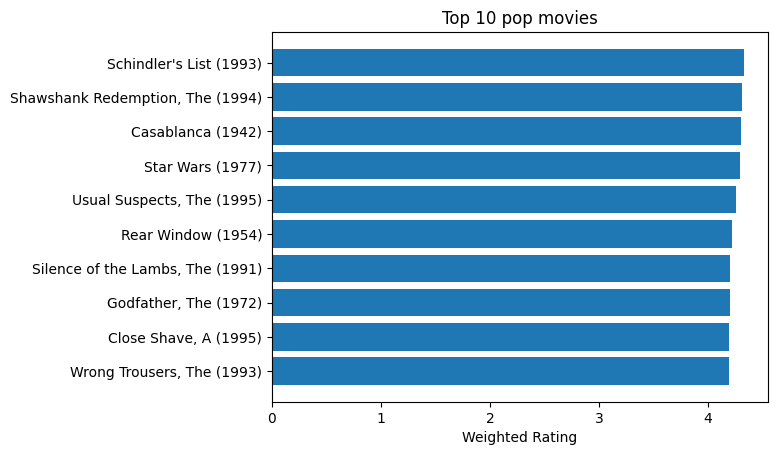

In [8]:
# Visualize popular movies

top10 = popular_movies.head ( 10 )

plt. barh ( top10['title'], top10['weighted_rating'] ) # as this is horizontal plot 1st-yaxis, 2nd value x- axis

plt.xlabel ( 'Weighted Rating' )

plt.title ( 'Top 10 pop movies' ) 

plt.gca().invert_yaxis() # by default the graph will show the highest value in bottom (kindof ascending) so we are inverting to make the popular movie on the top

# plt.gca() = “get current axes” (the current plot).

plt.show()

In [9]:
# WEIGHTED RATING

#Formula (IMDB style):

#WR = {v}/{v+m} R + {m}/{v+m} C

#Where:

# R = average rating for movie

# v = number of ratings for movie

# m = minimum ratings required (e.g., 50)

# C = mean rating across all movies

C = df [ 'rating' ].mean()

m = 100

def weighted_rating ( x, m = m, C = C ):
    
    v = x ['num_rating']
    
    R = x [ 'avg_rating' ]
    
    return (v / ( v + m )) * R + ( m / ( v + m ) ) * C

popular_movies [ 'weighted_rating' ] = popular_movies.apply ( weighted_rating, axis = 1 )

popular_movies = popular_movies.sort_values ( 'weighted_rating', ascending = False )

popular_movies.head(10)


#What apply does
#DataFrame.apply(func, axis=1) → applies a function row by row.

#Each row is temporarily treated like a Series (a dictionary‑like object with column names as keys).

#The function receives that row (x) and returns a single value.

#Pandas collects all those returned values into a new column.



,title,avg_rating,num_rating,weighted_rating
1398,Star Wars (1977),4.358491,583,4.237168
1281,Schindler's List (1993),4.466443,298,4.231121
1317,"Shawshank Redemption, The (1994)",4.445230,283,4.206230
273,Casablanca (1942),4.456790,243,4.186548
1572,"Usual Suspects, The (1995)",4.385768,267,4.152550
612,"Godfather, The (1972)",4.283293,413,4.136425
1329,"Silence of the Lambs, The (1991)",4.289744,390,4.134665
1205,Raiders of the Lost Ark (1981),4.252381,420,4.113435
1215,Rear Window (1954),4.387560,209,4.109987
1500,Titanic (1997),4.245714,350,4.086636


In [10]:
# Count the movis with values less than 50

unpopular_movies = movie_stats [ movie_stats [ 'num_rating' ] < 50 ] # only movies with <= 50

print ( "popular_movies - ", popular_movies.shape[0] )

print ( "unpoppular < 50 - ", unpopular_movies.shape[0] ) # This gives the number of rows (movies with ≤ 50 ratings).

print ( unpopular_movies.count() ) # This counts non‑null values per column

over_popular_movies = movie_stats [ movie_stats [ 'num_rating' ] >= 100 ] # only movies with = 100

over_popular_movies = over_popular_movies.sort_values ( 'avg_rating', ascending = False )

over_popular_movies.head(10)

print ("``````````````Over_Popular`````````````")

print ( "over popular_movies > 100", over_popular_movies.shape[0] )

popular_movies -  605
unpoppular < 50 -  1059
title         1059
avg_rating    1059
num_rating    1059
dtype: int64
``````````````Over_Popular`````````````
over popular_movies > 100 338


Perfect! 🔥 You are already thinking like a real ML engineer, not just running code. Let’s break down what your results are telling you.


---

✅ Observations from Your Analysis

1️⃣ Threshold = 50 (m = 50)

Popular movies ≥50 ratings: 605 movies

Less popular (<50 ratings): 1059 movies
→ Shows majority of movies have very few ratings → dataset is sparse.

Top movies weighted rating adjusts slightly down from the raw average (0.1-0.15 difference).


Why this matters:
Weighted rating reduces the impact of small sample bias. For example, a movie with only 3 ratings of 5.0 shouldn’t appear as “top movie” because it’s not representative.


---

2️⃣ Threshold = 100 (m = 100)

Popular movies ≥100 ratings: 338 movies

Now top movies slightly shuffle. For example, “Star Wars (1977)” moves to the top.


Why this matters:

Higher threshold → fewer movies considered → more reliable top movies.

Balances between quantity of votes and quality.



---

3️⃣ Weighted Rating Insight

Weighted rating formula:

WR = \frac{v}{v+m} R + \frac{m}{v+m} C

Where:

v = number of ratings for movie

R = average rating for movie

C = mean rating across all movies

m = minimum votes threshold


Observations from your table:

Schindler’s List raw avg = 4.466 → weighted = 4.331

Godfather raw avg = 4.283 → weighted = 4.202

Movies with more ratings get less penalized → shows weighted rating handles “popularity bias” fairly.



---

4️⃣ Why thresholds matter

m = 50 → more movies considered → smaller skew, but still some small-vote movies appear.

m = 100 → only well-rated, widely-watched movies → high confidence recommendations.

This is exactly how IMDB / Netflix / Amazon decide trending items.



---

5️⃣ Big Industry Insight

Popularity-based recommenders are non-personalized:

Every user sees same top movies.


Simple, but extremely useful for:

Cold-start users (new users with no ratings)

Quickly testing pipeline logic


Sets the stage for collaborative filtering next:

Then recommendations become personalized.




---

💡 Observation you already made well:

> Because it ensures minimum number of votes, else if only 3 person give a movie above 4, means that data is skewed/biased. Not representing everyone’s opinions.



Exactly! That is the reasoning behind using m in weighted rating — this is how real-world systems avoid fake hype.


---

If you want, the next step (Day 3) will be to make this personalized for users using User-Based Collaborative Filtering.
Then, we can recommend movies like Netflix or Amazon would.


---

I can also show a visual plot of top 10 weighted movies for m=50 and m=100 so you can see the difference instantly, like a real dashboard.

Do you want me to do that next?

